# EV Battery Health Prediction (SoH) with Linear Regression

**Research question:** Can we predict the **State of Health (SoH)** of an electric-vehicle (EV) battery from its charging/usage data?

**What is SoH?** SoH is the ratio of the battery's current capacity to its capacity when new, expressed as a percentage:

$$\text{SoH} = \frac{\text{current max capacity}}{\text{nominal (new) capacity}} \times 100\%$$

A brand-new battery has SoH = 100\%. A battery that holds only 80\% of its original charge is usually considered **end of life** for an EV. Predicting SoH from sensor data (charge cycles, temperature, voltage, current, internal resistance, ...) is a classic **regression** problem, and Linear Regression is the simplest, most interpretable model to start with.

### Notebook outline
1. Load and inspect the data
2. Clean and preprocess (missing values, categorical encoding, feature selection)
3. Split into training (80%) and test (20%) sets
4. Train a Linear Regression model
5. Evaluate with R-squared and RMSE
6. Plot actual vs predicted SoH and save the figure


## 1. Import the libraries we need

We use four libraries:
- **pandas**: reading and manipulating tabular data (the CSV file)
- **numpy**: fast math on numbers (we use it for the square root in RMSE)
- **matplotlib**: drawing the final plot
- **scikit-learn (sklearn)**: machine learning — the model and the metrics


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error


## 2. Load the dataset

The CSV file lives in the `data/` folder (downloaded from Kaggle). We do not hard-code the exact file name: the cell below searches for **any** `.csv` file inside `data/`, the current folder, and the parent folder, so it works no matter how the file is named after download.


In [2]:
def find_dataset_csv():
    """Look for a CSV file in the most likely locations and return its path."""
    # Directories to search, in order of preference.
    search_dirs = [
        os.path.join(os.getcwd(), "data"),   # data/ next to the notebook
        os.getcwd(),                          # same folder as the notebook
        os.path.join(os.getcwd(), ".."),      # one folder up
    ]
    for folder in search_dirs:
        if os.path.isdir(folder):
            # Collect every .csv file in this folder
            csv_files = [f for f in os.listdir(folder) if f.lower().endswith(".csv")]
            if csv_files:
                return os.path.join(folder, csv_files[0])
    return None

csv_path = find_dataset_csv()
if csv_path is None:
    raise FileNotFoundError(
        "No CSV file found. Download the dataset from Kaggle "
        "and place it in the data/ folder."
    )

print("Reading:", csv_path)

# Load the CSV into a pandas DataFrame
df = pd.read_csv(csv_path)

# Basic sanity check: how many rows and columns do we have?
print("Shape (rows, columns):", df.shape)
print()
print(df.head())


Reading: C:\Users\LENOVO\OneDrive\Documents\ev-battery-health-prediction\data\EV_Battery_Data.csv
Shape (rows, columns): (2000, 13)

  BatteryID BatchID  Cycle   Voltage   Current  Temperature  ChargeTime  \
0   BAT0001  BatchC      1  3.654514  0.917553    25.888505   37.618388   
1   BAT0002  BatchD      2  3.160100  1.697440    18.323278   40.734450   
2   BAT0003  BatchA      3  3.829972  0.989381    26.900989   50.212414   
3   BAT0004  BatchC      4  3.954014  0.949075    28.052929   75.017814   
4   BAT0005  BatchC      5  3.196025  0.848759    27.798952  105.639848   

   DischargeTime  InternalResistance  Capacity  AmbientHumidity    C_Rate  \
0      37.044703            0.052224  2.500157        46.924728  1.158642   
1     114.007199            0.049553  2.491344        66.132587  1.229915   
2      62.681933            0.050329  2.496170        49.332729  1.939330   
3     106.023825            0.052222  2.507784        52.957813  1.599029   
4      67.654500            0.0

## 3. Understand the columns

Before doing anything, we look at the **column names and data types**. We do not assume the exact names from the Kaggle page (they can change between uploads). Instead the cells below **auto-detect**:
- the **target column** `y` (the one containing "soh" / "state of health"),
- the **categorical column** (battery chemistry: NMC vs LFP — stored as text),
- the **numeric features** `X` (everything else that is a number).


In [3]:
# Show all column names and their data types
print(df.dtypes)
print()
print("All columns:", list(df.columns))


BatteryID                 str
BatchID                   str
Cycle                   int64
Voltage               float64
Current               float64
Temperature           float64
ChargeTime            float64
DischargeTime         float64
InternalResistance    float64
Capacity              float64
AmbientHumidity       float64
C_Rate                float64
SOH                   float64
dtype: object

All columns: ['BatteryID', 'BatchID', 'Cycle', 'Voltage', 'Current', 'Temperature', 'ChargeTime', 'DischargeTime', 'InternalResistance', 'Capacity', 'AmbientHumidity', 'C_Rate', 'SOH']


In [4]:
# --- Auto-detect the target column (SoH) ------------------------------
# Normalise the names: lowercase and remove spaces/underscores,
# so "SoH", "soh" and "State_of_Health" all match.
normalised = {c: c.lower().replace(" ", "").replace("_", "") for c in df.columns}

target_candidates = [c for c, n in normalised.items() if "soh" in n]
if not target_candidates:
    raise ValueError("Could not find the SoH target column in the dataset.")

target_column = target_candidates[0]
print("Detected target column:", target_column)

# --- Auto-detect the battery chemistry (categorical) column --------------
chem_candidates = [c for c, n in normalised.items() if "chem" in n]
print("Detected chemistry column(s):", chem_candidates)

# --- Decide which columns are NOT useful as features ---------------------
# ID columns (battery numbers, rows IDs, ...) are unique per row and
# would just add noise, so we drop them.
id_like = [c for c in df.columns if c.lower().replace("_", "") in
           ("batteryid", "batchid", "id", "index", "vpn", "vpnkey", "cellid", "evid")]
print("Dropping ID-like column(s):", id_like)


Detected target column: SOH
Detected chemistry column(s): []
Dropping ID-like column(s): ['BatteryID', 'BatchID']


In [5]:
# Separate the raw DataFrame into:
#  - y: the target we want to predict (SoH)
#  - features_raw: everything else that could be useful
y = df[target_column]
features_raw = df.drop(columns=[target_column] + id_like)

# Keep only useful columns:
#  - numeric columns -> direct features
#  - text columns -> candidates for one-hot encoding (e.g. the chemistry)
numeric_features = features_raw.select_dtypes(include=[np.number]).columns.tolist()
object_features = [
    c for c in features_raw.columns
    if pd.api.types.is_string_dtype(features_raw[c])
]

# Text columns with MANY unique values (e.g. timestamps) are not real
# categories. Encoding them would create thousands of useless dummy columns,
# so we drop them.
high_cardinality = [c for c in object_features if features_raw[c].nunique() > 20]
if high_cardinality:
    print("Dropping high-cardinality text columns:", high_cardinality)
object_features = [c for c in object_features if c not in high_cardinality]

print("Numeric features:", numeric_features)
print("Object (categorical) features:", object_features)

# The chemistry column should be exactly one of the object columns.
# If none was found, we set it to None (the dataset may already be encoded).
chemistry_column = chem_candidates[0] if len(chem_candidates) == 1 else None
print("Using chemistry column:", chemistry_column)


Numeric features: ['Cycle', 'Voltage', 'Current', 'Temperature', 'ChargeTime', 'DischargeTime', 'InternalResistance', 'Capacity', 'AmbientHumidity', 'C_Rate']
Object (categorical) features: []
Using chemistry column: None


## 4. Handle missing values

A quick sanity check for `NaN` (not-a-number) cells. If only a few rows contain missing values we simply **drop those rows** — with ~10,000 samples we lose almost nothing, and it is the simplest and safest option.


In [6]:
# Count missing values per column
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.any() else "None - the dataset is complete.")

# Drop any row that contains a missing value.
# .dropna() returns a new DataFrame; inplace=False keeps the original untouched.
df_clean = df.dropna()
print()
print("Rows before cleaning:", len(df))
print("Rows after cleaning :", len(df_clean))


Missing values per column:
None - the dataset is complete.

Rows before cleaning: 2000
Rows after cleaning : 2000


## 5. Encode any categorical (text) columns

Machine learning models only understand **numbers**, not text. `pd.get_dummies()` converts a text column with a few distinct values (e.g. a battery-chemistry code like "NMC" / "LFP") into 0/1 indicator columns ("one-hot encoding").

In this dataset the identifier columns (`BatteryID`, `BatchID`) are dropped and the remaining columns are all numeric, so this step typically does nothing here — but it keeps the pipeline reusable for datasets that *do* contain a text column.


In [7]:
# Start from the cleaned data and re-split target / features
y = df_clean[target_column]
features_raw = df_clean.drop(columns=[target_column] + id_like)

# Recompute the numeric and text feature lists on the cleaned data.
# Drop high-cardinality text columns (e.g. timestamps) again.
text_features = [
    c for c in features_raw.columns
    if pd.api.types.is_string_dtype(features_raw[c])
]
high_card = [c for c in text_features if features_raw[c].nunique() > 20]
if high_card:
    print("Dropping high-cardinality text columns:", high_card)
    features_raw = features_raw.drop(columns=high_card)

numeric_features = features_raw.select_dtypes(include=[np.number]).columns.tolist()
object_features = [
    c for c in features_raw.columns
    if pd.api.types.is_string_dtype(features_raw[c])
]

if object_features:
    # One-hot encode every text column (expected: the chemistry column)
    encoded = pd.get_dummies(features_raw[object_features], drop_first=True)
    print("Encoded categorical columns:", list(encoded.columns))
    # Combine the encoded columns with the numeric ones
    X = pd.concat([features_raw[numeric_features], encoded], axis=1)
else:
    X = features_raw[numeric_features]

y = y.astype(float)
print()
print("Final feature matrix X shape:", X.shape)
print("Feature names:", list(X.columns))
print()
print("Target y statistics (SoH):")
print(y.describe())



Final feature matrix X shape: (2000, 10)
Feature names: ['Cycle', 'Voltage', 'Current', 'Temperature', 'ChargeTime', 'DischargeTime', 'InternalResistance', 'Capacity', 'AmbientHumidity', 'C_Rate']

Target y statistics (SoH):
count    2000.000000
mean       61.293052
std        18.481668
min        27.791377
25%        45.290571
50%        61.085327
75%        76.830696
max       100.000000
Name: SOH, dtype: float64


## 6. Split into training and test sets (80 / 20)

We split the data so the model **learns on 80%** (training set) and is **evaluated on 20% it has never seen** (test set). This is the honest way to measure how well the model generalises to new batteries.

- `test_size=0.2` → 20% for testing
- `random_state=42` → fixed seed, so the split is the same every time you re-run (reproducible results)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training rows:", X_train.shape[0], f"({len(X_train) / len(X) * 100:.0f}%)")
print("Testing rows :", X_test.shape[0], f"({len(X_test) / len(X) * 100:.0f}%)")


Training rows: 1600 (80%)
Testing rows : 400 (20%)


## 7. Train the Linear Regression model

Linear Regression fits a straight (hyper)line through the data:

$$\text{SoH} = b_0 + b_1 \cdot x_1 + b_2 \cdot x_2 + \dots + b_n \cdot x_n$$

where the $b$ coefficients are chosen to minimise the squared error on the training data. sklearn does all the math in one line with `.fit()`.


In [9]:
# Create the model object
model = LinearRegression()

# Train it on the training data (fit = learn the best coefficients)
model.fit(X_train, y_train)

print("Model trained successfully.")
print()
print("Learned intercept (b0):", round(model.intercept_, 4))

# The coefficient of each feature tells us the expected change in SoH
# for a one-unit increase of that feature (all else being equal).
for feature, coef in zip(X.columns, model.coef_):
    print(f"  coefficient for '{feature}': {coef:+.6f}")


Model trained successfully.

Learned intercept (b0): 94.4984
  coefficient for 'Cycle': -0.032229
  coefficient for 'Voltage': -0.099731
  coefficient for 'Current': -0.063880
  coefficient for 'Temperature': -0.022395
  coefficient for 'ChargeTime': -0.000934
  coefficient for 'DischargeTime': -0.001423
  coefficient for 'InternalResistance': +2.385604
  coefficient for 'Capacity': -0.097175
  coefficient for 'AmbientHumidity': -0.000338
  coefficient for 'C_Rate': +0.056219


## 8. Evaluate the model on the test set

Two standard metrics for regression:

- **R-squared (R²)**: fraction of the variance in the real SoH that the model explains. `1.0` = perfect prediction, `0.0` = no better than predicting the mean.
- **RMSE (Root Mean Squared Error)**: the average prediction error, measured in the **same units as SoH** (here a percentage). An RMSE of ~1 means predictions are typically off by about 1 percentage point of health.


In [10]:
# Predict SoH for the test set (data the model has never seen)
y_pred = model.predict(X_test)

# R-squared
r2 = r2_score(y_test, y_pred)

# RMSE = sqrt(mean of squared errors), computed step by step for clarity
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("=" * 50)
print("EV BATTERY HEALTH PREDICTION - RESULTS")
print("=" * 50)
print(f"Model              : Linear Regression")
print(f"Training samples   : {X_train.shape[0]:,}")
print(f"Test samples       : {X_test.shape[0]:,}")
print(f"R-squared (R²)     : {r2:.4f}")
print(f"RMSE               : {rmse:.4f} (SoH percentage points)")
print("=" * 50)


EV BATTERY HEALTH PREDICTION - RESULTS
Model              : Linear Regression
Training samples   : 1,600
Test samples       : 400
R-squared (R²)     : 0.9967
RMSE               : 1.0804 (SoH percentage points)


## 9. Visualise: actual vs predicted SoH

Each dot is one battery in the **test set**:
- **x-axis**: its real (measured) SoH
- **y-axis**: the SoH our model predicted

If predictions were perfect, every dot would lie exactly on the red dashed **diagonal line** `y = x`. The tighter the dots hug the line, the better the model. The figure is saved as `images/result_plot.png`.


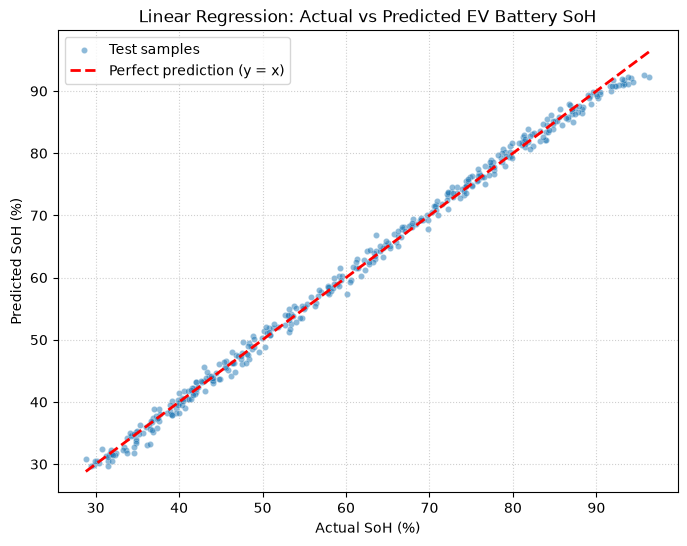

Plot saved to: images/result_plot.png


In [11]:
fig, ax = plt.subplots(figsize=(8, 6))

# Scatter plot of actual (x) vs predicted (y) SoH on the test set
ax.scatter(y_test, y_pred, alpha=0.5, s=20, edgecolor="white", linewidth=0.3, label="Test samples")

# Diagonal reference line: the perfect-prediction line y = x
line_min = min(y_test.min(), y_pred.min())
line_max = max(y_test.max(), y_pred.max())
ax.plot([line_min, line_max], [line_min, line_max], "r--", linewidth=2,
        label="Perfect prediction (y = x)")

ax.set_xlabel("Actual SoH (%)")
ax.set_ylabel("Predicted SoH (%)")
ax.set_title("Linear Regression: Actual vs Predicted EV Battery SoH")
ax.legend()
ax.grid(True, linestyle=":", alpha=0.6)

# Save the figure to the images/ folder (also shown below in the notebook)
os.makedirs("images", exist_ok=True)
fig.savefig("images/result_plot.png", dpi=150, bbox_inches="tight")

plt.show()
print("Plot saved to: images/result_plot.png")


## 10. What do the results mean?

- **R²** tells us what fraction of the differences between batteries is explained by the model. The closer to 1, the more the chosen features (cycles, temperature, voltage, driving patterns, ...) actually drive battery degradation.
- **RMSE** is the typical prediction error in the same units as SoH (here percentage points). An RMSE of ~1 means "on average our predicted SoH is within about 1 percentage point of the true value".
- Healthy batteries start at 100% and degrade toward ~28% in the most aged samples, so even a small error matters for safety and warranty decisions — which is why we look at both metrics together.

**Why Linear Regression?**
1. Battery degradation is *roughly linear* with charge cycles in the early/mid life of the pack (capacity fades at a fairly constant rate).
2. It is the simplest model to explain and debug — perfect for a baseline in a course project.
3. The learned coefficients directly tell us *which* factors matter (e.g. negative coefficient on charge cycles = more cycles → lower SoH).

If R² is low, a reasonable next step would be trying a non-linear model (e.g. Random Forest or Polynomial Regression) — but for a first, interpretable model Linear Regression is the right starting point.
